In [29]:
%load_ext autoreload
%autoreload 2

from utils import *
plt.rcParams['figure.dpi'] = 100 

data = load_data("data")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 1 Binary Modulation

In this section, we classify each trial by its running-speed trace:
- `Run` trials have mean speed above 3.0 cm/s with every frame above 0.5 cm/s; 
- `Still` trials have mean speed below 0.5 cm/s with every frame below 3.0 cm/s; 
- All remaining trials are ignored.

In this way, we want to study the running modulation to neuron's response with clean, well-classified trial states.

run analysis 

In [30]:
modulation_results = run_binary_modulation_analysis(
    data,
    RESPONSE_WINDOWS,
    run_threshold=3.0,
    still_threshold=0.5,
    min_trials_per_state=2,
    min_gain_conditions=3,
)
n_neurons = len(data["matched_cell_ids"])
print("Matched cells:", n_neurons)

Matched cells: 47


In [31]:
run_summary = summarize_binary_modulation_runs(modulation_results)
run_summary[["stimulus", "n_trials", "n_running", "n_still", "n_ignored"]]

,stimulus,n_trials,n_running,n_still,n_ignored
0,drifting_gratings,598,195,25,378
1,static_gratings,5811,1825,1910,2076
2,natural_scenes,5900,1315,1902,2683
3,spontaneous,1186,281,271,634


Both states are populated in every stimulus, so the running-versus-still contrast is defined throughout. The balance is strongly skewed for DG, which retains only 28 still trials against 195 running trials, whereas SG and NS retain thousands of each. DG estimates therefore rest on far less still data than the other stimuli.

## 1.1 Modulated neurons
Under different stimuli types, for each neuron, computed the average response of `run` trials $R_{\mathrm{run,c}}$ and `still` trials $R_{\mathrm{run,c}}$ for each conditions, then computed the evoked response $\Delta R_c$ for the conditions:
$$ \Delta R_c = R_{\mathrm{run, c}} - R_{\mathrm{still, c}}$$

Then gather together $\Delta R_c$ for all conditions under one stimuli type, test whether it is significantly different from 0, if so then the neuron is **modulated by running** under the stimuli type.

For `spont`, do Wilcoxon rank-sum test of all $R_{\mathrm{run}}$ and $R_{\mathrm{still}}$.

<mark>The following analysis will be concentrated at the **modulated neurons** obtained here.</mark>

In [32]:
# to obtain the modulated neurons under different stimuli (and spont)
modulated_mask = {stim: modulation_results[stim].modulated_mask for stim in STIMULI}

====== drifting_gratings: n=1 =====
 [39]
====== static_gratings: n=29 =====
 [ 1  4  6  9 11 13 14 15 16 17 20 21 23 25 27 28 29 30 31 34 36 37 38 39
 40 43 44 45 46]
====== natural_scenes: n=30 =====
 [ 0  1  3  4  8 10 11 13 15 16 18 20 21 23 24 25 29 30 31 32 34 35 36 37
 39 40 42 44 45 46]
====== spontaneous: n=19 =====
 [ 0  1  2  4  8 13 15 16 19 21 23 24 25 28 29 35 36 38 40]


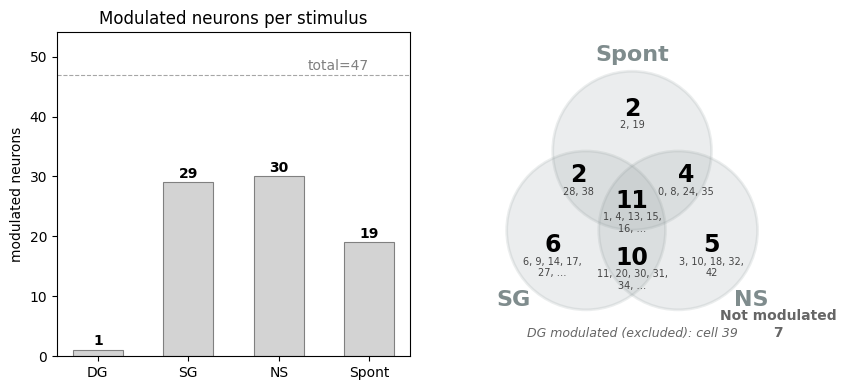

In [33]:
# modulated neuron counts per stimulus
for stim in STIMULI:
    modulation_results[stim].print_modulated_cells()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4),
                                 gridspec_kw={'width_ratios': [1, 1.3]})
plot_modulated_counts(modulated_mask, total_cells=47, ax=ax1)
ax1.set_title('Modulated neurons per stimulus')
plot_modulated_venn(modulated_mask, ax=ax2)

# plt.savefig("doc/figures/modulated_neurons_counts.png")
plt.show()

## 1.2 Sign-safe MI

For the modulated neurons, compute the sign-safe MI under different stimuli types:

$$
MI_{\mathrm{safe}} = \frac{R_{\mathrm{run}} - R_{\mathrm{still}}}
{|R_{\mathrm{run}}| + |R_{\mathrm{still}}| + \epsilon} \in [-1,1]
$$

with $\epsilon = 10^{-12}$ preventing division by zero. Its denominator is never negative, so MI_safe is bounded in [-1, 1] and always carries the sign of $R_{\mathrm{run}} - R_{\mathrm{still}}$. The denominator-free sensitivity measure is $\Delta R = R_{\mathrm{run}} - R_{\mathrm{still}}$.

> The original $MI=\frac{R_{\mathrm{run}} - R_{\mathrm{still}}} {R_{\mathrm{run}} + R_{\mathrm{still}}}$ suffers from negative values of responses ΔF/F, which shouldn't be simply removed as noise.

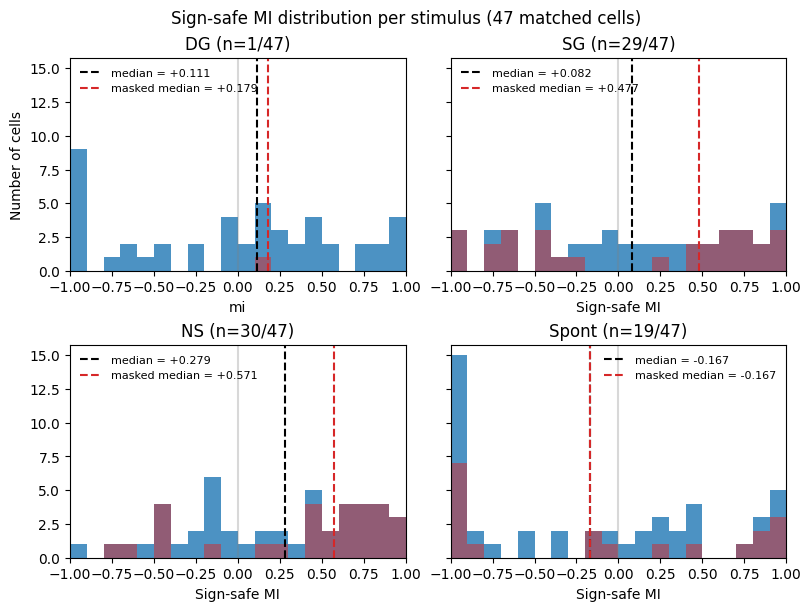

In [34]:
# plot the distribution (highlight for modualted neurons)
fig, axes = plot_metric_comparison(modulation_results, metric="mi", neurons_mask=modulated_mask)
for i, ax in enumerate(axes):
    if i/2 > 0:
        ax.set_xlabel("Sign-safe MI")
fig.suptitle("Sign-safe MI distribution per stimulus (47 matched cells)")
# plt.savefig("doc/figures/MI_histogram_populations.png")
plt.show()

Deviations between $MI_{\mathrm{safe}}$ and modulated neurons based on $\Delta R$ is observed here. It comes from the difference of the two quantities: 
- $\Delta R$ is the exact difference between responses when running or still. A neuron would be marked 'modulated' if $\Delta R$ stably deviate zero, even though its absolute value might be small.
- $MI_{\mathrm{safe}}$ measures the effect size of the modulation, regardless of its variance across trials. A large $|MI_{\mathrm{safe}}|$ does not necesserily means the neuron is significantly modulated by running.

**Therefore, $MI_{\mathrm{safe}}$ is meaningful only for the modulated neurons here.**

> For DG, it suffers from few trials numebers, therefore the significance test is unreliable.

## 1.3 Gain analysis

For each modulated neuron under different stimuli, fits a simple gain model using run-still pairs of all conditions: 

$$
R_{\mathrm{run,c}} = a \cdot R_{\mathrm{still,c}} + b
$$

, where $a$ is the multiplicative slope, $b$ is the additive offset, and $R²$ measures how well one linear gain relation explains condition-level variation. 

A large slope does not imply a strong fit when $R²$ is low, because the line can pass through a widely scattered cloud of conditions. Spontaneous activity has no condition structure and is excluded.

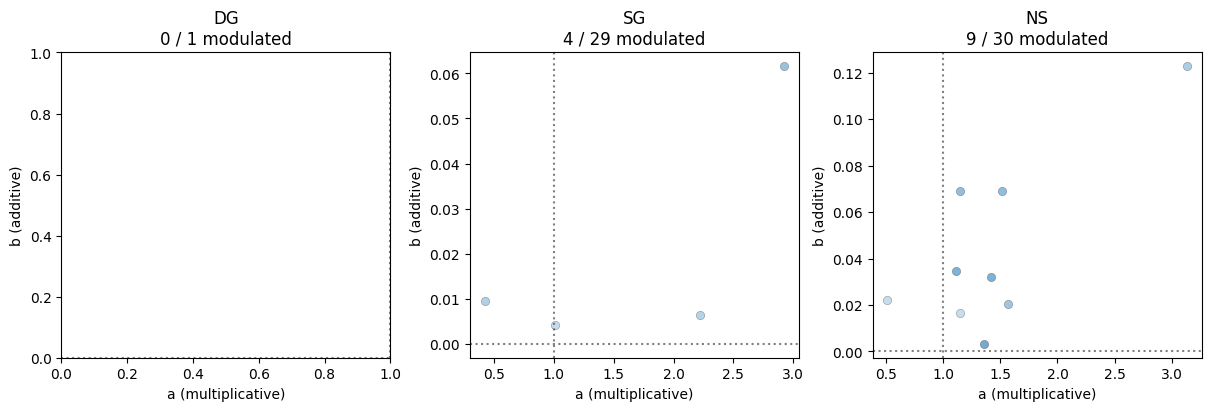

In [35]:
plot_gain_scatter(modulation_results, r2_threshold=0.2) # TODO other way to evaulate the results
plt.show() 

An example neuron

--- Representative Cell 42 (natural_scenes) ---
Slope (a) : 0.499
Offset (b): +0.0072
R^2       : 0.023 (Population Median = 0.023)


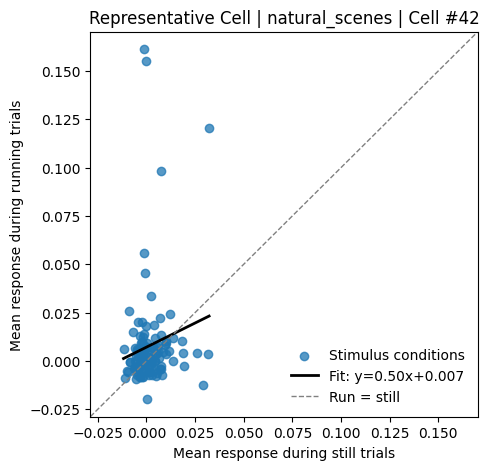

In [36]:
stimulus = "natural_scenes"
analysis = modulation_results[stimulus]

valid_mask = analysis.gain_valid & (analysis.n_gain_conditions >= 10)
eligible_cells = np.where(valid_mask)[0]

if not len(eligible_cells):
    raise ValueError(f"No eligible cells found for stimulus: {stimulus}")

r2_values = analysis.gain_r2
a_values = analysis.gain_a
b_values = analysis.gain_b

population_median_r2 = np.nanmedian(r2_values[valid_mask])
r2_diffs = np.abs(r2_values[eligible_cells] - population_median_r2)
example_cell = eligible_cells[np.nanargmin(r2_diffs)]
print(
    f"--- Representative Cell {example_cell} ({stimulus}) ---\n"
    f"Slope (a) : {a_values[example_cell]:.3f}\n"
    f"Offset (b): {b_values[example_cell]:+.4f}\n"
    f"R^2       : {r2_values[example_cell]:.3f} "
    f"(Population Median = {population_median_r2:.3f})"
)

analysis.plot_cell_gain_fit(cell=example_cell)
plt.title(f"Representative Cell | {stimulus} | Cell #{example_cell}")
plt.show()


A grid map of modulated neurons and their gain

/Users/eastos/Projects/Course/ST26/NDS-V1-RunningNaturalMod/utils.py:3404: RuntimeWarning: Mean of empty slice
  gain_a_means = np.nanmean(np.where(mod_mask, gain_a_vals, np.nan), axis=1)


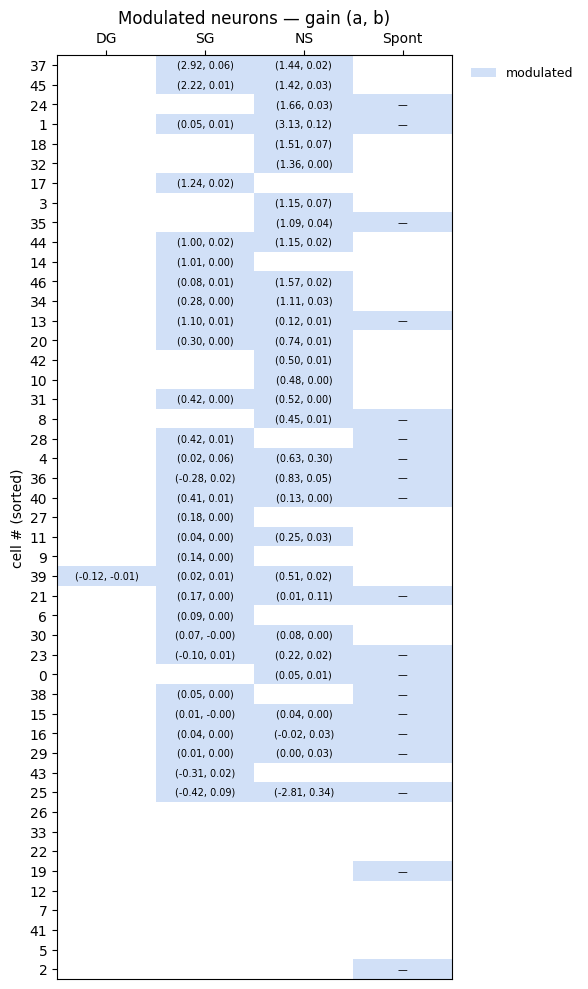

In [37]:
fig = plot_modulation_grid(modulation_results) # TODO improve the plotting
plt.show()

---

# 2 Speed Tuning

In this section, we studied the modulation by running speed through binning the resposne ΔF/F by running speeds into e.g. 20 bins, and thereby obtained the tuning curve of the modulated neurons.

Tuning computed over all trials; speed-distribution imbalance balanced by subsampling.

In [38]:
trial_data_dict = {stim: extract_trials(data, stimulus=stim) for stim in STIMULI}
# trial_blank_dict = {stim: extract_blank_trials(data, stimulus=stim) for stim in STIMULI[:-1]}
mode = 'equal_size' # mode of binning

Here we filter out the 'preferred' conditions of each neuron under different stimuli types. `top_frac` controls the fraction of which conditions should be taken into account.

> Considering the effect of stimuli, ideally we should pick the *top one* 'preferred' condition of each neurons to compute the tuning to speed, otherwise it's hard to say whether a higher response under a specific speed actually come from the preferred conditions by coincidence. 
>
> However, one condition here only have less than 50 trials, which is too rare to be binned. We also tried making use of the `blank_sweep` trials within the stimuli period, compute its mean and std as baseline, and then pick conditions whose mean responses is larger than mean ± std. In this way, the picked trials are still too rare, and even zero for some neurons nonsensitive to specific type of stimuli.
>
> Therefore, we have to make the tuning tolerant to this effect. By setting a argument `top_frac`, we pick the a fraction of the trials with larger responses.

In [39]:
# compute the mean response of these neurons over conditions, regardless of running speed, to find the neurons' 'preferred condition' of each stimuli.
top_frac = 1
pref_trial_masks = {stim: find_preferred_conditions(trial_data_dict[stim], top_frac)[1] for stim in STIMULI[:-1]}
pref_trial_masks["spontaneous"] = None

run the tuning analysis all-in-one

In [40]:
# SpeedTuning — spontaneous uses neuron_mask=None (all 47 cells) so its mean_all_responses
# can be indexed by other stimuli's neuron_mask for baseline overlay

tunings = {stim: SpeedTuning(trial_data_dict[stim], mode=mode,
                              neuron_mask=modulated_mask[stim] if stim != 'spontaneous' else None,
                              pref_trial_mask=pref_trial_masks[stim])
           for stim in STIMULI}

for stim in STIMULI:
    tunings[stim].run()

Below shows the imbalance of data across running speed, where low-speed trials is the absolutely most. Therefore we subsampled it to balance the distribution. 

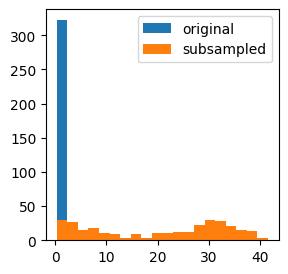

In [41]:
st_sg = tunings['drifting_gratings']
fig = plt.figure(figsize=(3,3))
plt.hist(st_sg.speeds, bins=st_sg.bins_edges,label='original')
sub_speeds = st_sg.speeds[st_sg.bins_sub_ids!=-1]
plt.hist(sub_speeds, bins=st_sg.bins_edges,label='subsampled')
# plt.yscale('log')
plt.legend()
plt.show()

## 2.1 Population tuning curve

First let's look at the tuning curve average over all modulated neurons. 

SG and NS both shows a increasing pattern in general, with some fluctuations in the middle, while Spont doesn't show a clear 'monotonic' pattern.

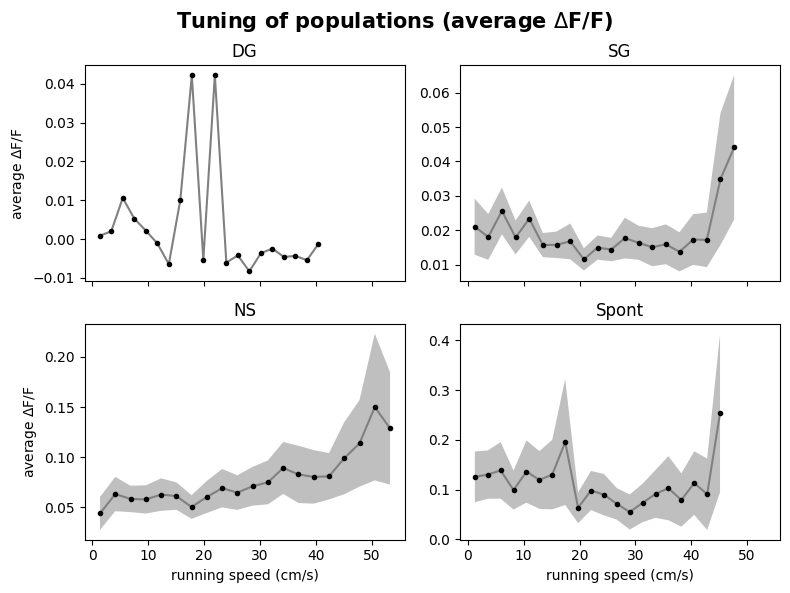

In [42]:
fig = plot_tuning_curves_grid(tunings, labels=STIMULI, modulated_mask=modulated_mask)
# axes[0,0].set_ylim(bottom=None)
plt.suptitle("Tuning of populations (average $\\Delta$F/F)", fontsize=15, fontweight='bold')
# plt.savefig("doc/figures/tuning_all_neurons.png")
plt.show()

## 2.2 Tuning profiles of modulated neurons

The population tuning curve can't tell us much, thereby we dived into each neuron's tuning profile, where we:
1. compute one-way ANOVA test on the tuning curve, to recognize the **tuned neurons** with $p<0.05$
2. for the tuned neurons, compute Spearman's $\rho$ on the tuning curve, to recognize the *monotonicity* of the neurons.
    - Neurons don't show clear monotonicity, i.e. $p>0.05$: `non-monotonic`
    - Neurons have $p<0.05$ and $\rho>0$: `positive`
    - Neurons have $p<0.05$ and $\rho<0$: `negative`

In this way, we divided the **modulated neurons** into three groups and thereby shows the detailed tuning profiles.

Below shows how many modulated neurons are also tuned for each stimuli.

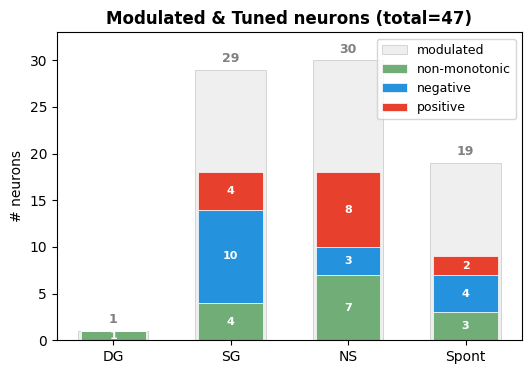

In [43]:
ax = plot_monotonicity_stacked_bar(tunings, modulated_mask=modulated_mask, figsize=(6, 4))
ax.set_title(f'Modulated & Tuned neurons (total={n_neurons})', fontweight='bold')
plt.savefig("doc/figures/tuned_neurons_numbers.png")
plt.show()

Here we plot out the average tuning curve of each subgroup (with MSE and average $|\rho|$), including the 3 groups introduced above as well as the non-tuned ones.

For the 3 stimuli, tuning curves under `Spont` of the same neurons are also plotted.

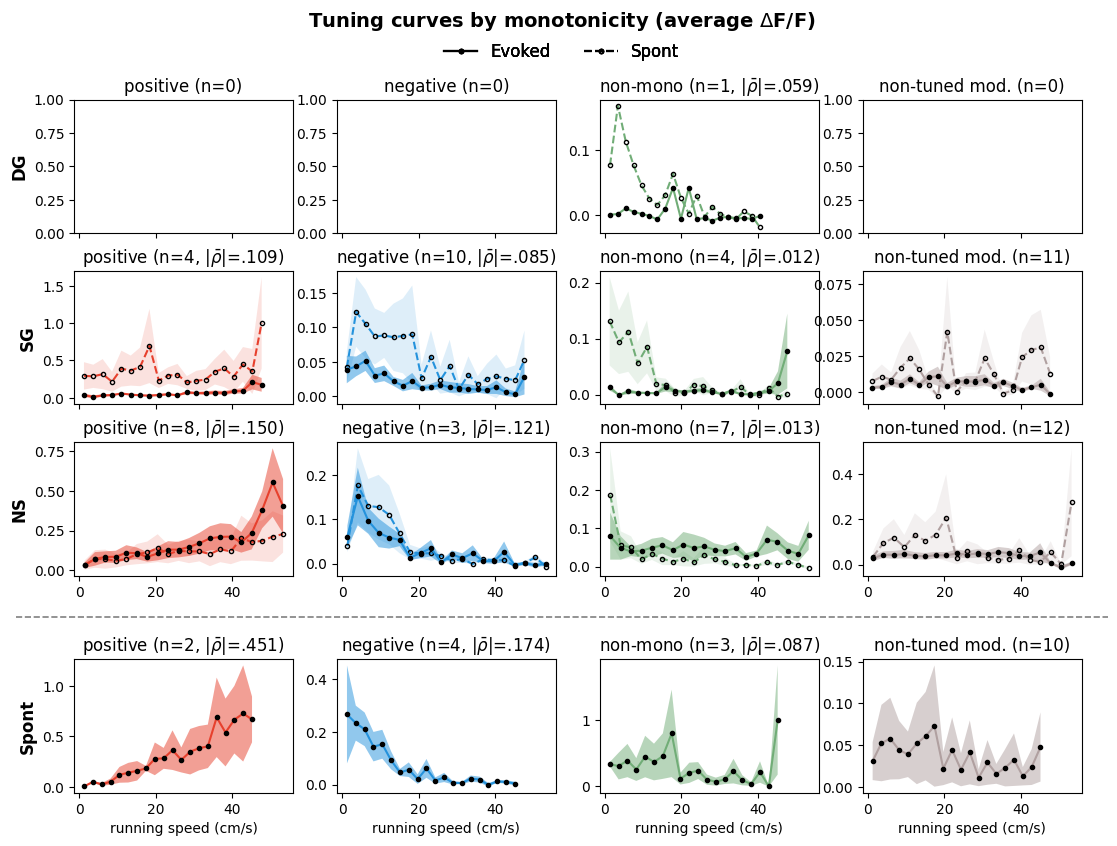

In [ ]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(13, 9))
gs = gridspec.GridSpec(5, 4, height_ratios=[1, 1, 1, 0.06, 1], hspace=0.35)
axes = np.array([[fig.add_subplot(gs[row, col]) for col in range(4)]
                  for row in range(5)])

# Hide spacer row (index 3)
for ax in axes[3]:
    ax.set_visible(False)

# Link all axes to share the same x-axis
for row in range(5):
    for col in range(4):
        if row != 3 and (row != 0 or col != 0):
            axes[row, col].sharex(axes[0, 0])

# Hide x-tick labels on rows 0-1; they'll be re-enabled on rows 2 and 4 below
for col in range(4):
    axes[0, col].tick_params(labelbottom=False)
    axes[1, col].tick_params(labelbottom=False)

plot_rows = [0, 1, 2, 4]

for plot_row, stim in zip(plot_rows, STIMULI):
    if stim == 'spontaneous':
        cells = np.where(modulated_mask['spontaneous'])[0]
        use_spont = None
    else:
        cells = None
        use_spont = tunings['spontaneous']
    tunings[stim].plot_tuning_by_monotonicity(
        axes=axes[plot_row], spontaneous=use_spont,
        modulated_mask=modulated_mask[stim],
        cells=cells,
        )
    axes[plot_row, 0].set_ylabel(stim_to_short(stim), fontsize=12, fontweight='bold')
    for ax in axes[plot_row]:
        ax.set_xlabel(None)

for col in range(4):
    axes[4, col].set_xlabel('running speed (cm/s)')
    # Show x-tick labels on NS row too
    axes[2, col].tick_params(labelbottom=True)

import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.suptitle('Tuning curves by monotonicity (average $\\Delta$F/F)', fontsize=14, fontweight='bold')

# Dashed separator between NS row and Spont row
from matplotlib.lines import Line2D
y_sep = (axes[2, 0].get_position().y0 + axes[4, 0].get_position().y1) / 2
fig.lines.append(Line2D([0.08, 0.92], [y_sep, y_sep], color='gray',
                         linestyle='--', linewidth=1.2,
                         transform=fig.transFigure, clip_on=False))

plt.savefig("doc/figures/tuning_by_monotonicity_allinone.png")
plt.show()

> The non-tuned neurons do not show a clear changes across different running speed, which suggests that they are only a run-or-not detector in the sense of running modulation.

Here we shows each neuron's tuning profile by a grid map. The float number denotes the Spearman's $\rho$, while the start marks denotes the p-value compured by one-way ANOVA.

/Users/eastos/Projects/Course/ST26/NDS-V1-RunningNaturalMod/utils.py:2050: RuntimeWarning: Mean of empty slice
  mean_abs_rho = np.nanmean(rho_stack, axis=0)


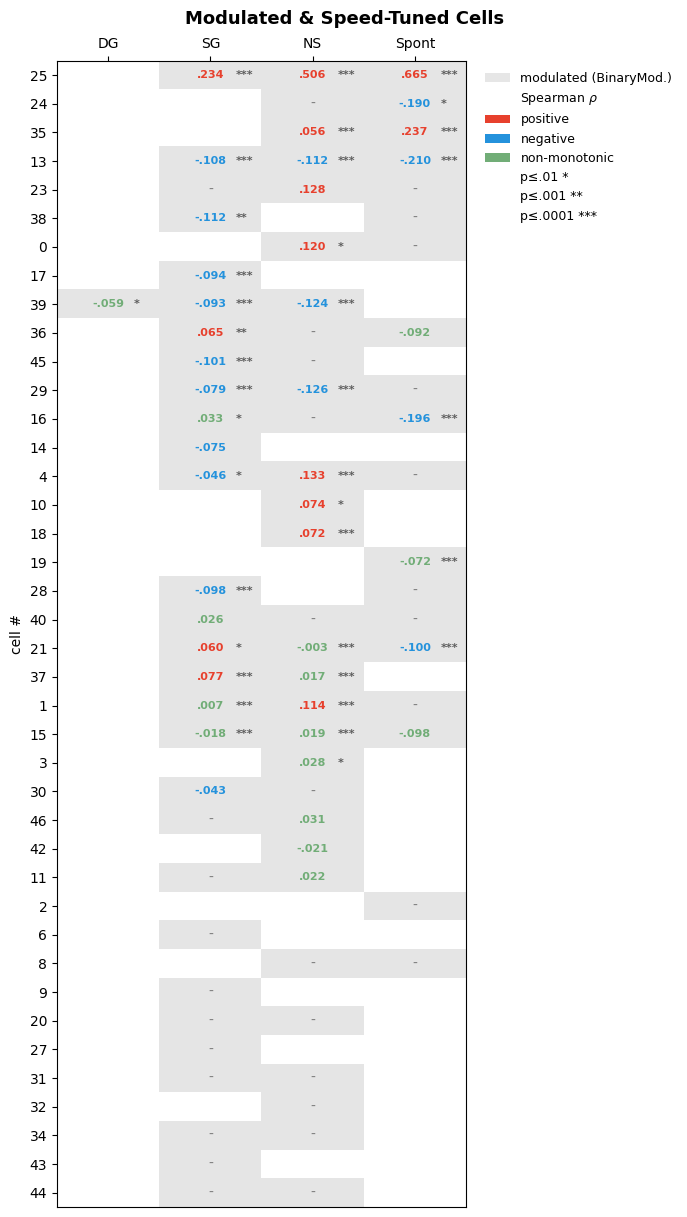

In [17]:
# plot a huge grid map (cell # by stimuli), containing (i) modulated mask (ii) p-value of tuning variance (ii) colored rho
fig = plot_modulated_tuned_grid(tunings, modulated_mask=modulated_mask,
                                 figsize=(7, 12))
fig.suptitle('Modulated & Speed-Tuned Cells',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig("doc/figures/tuning_profiles.png")
plt.show()